## Classificação (>= 2 modelos)

In [2]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

output_dir = r"E:\VISÃO COMPUTACIONAL\Projeto Final\OUTPUTS"

In [3]:
X = pd.read_csv(os.path.join(output_dir, 'X.csv'))
y = pd.read_csv(os.path.join(output_dir, 'y.csv')).squeeze()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClasses:", y.unique())
print("Distribuição:\n", y.value_counts())

X shape: (2286, 24)
y shape: (2286,)

Classes: <StringArray>
['fresh', 'rotten']
Length: 2, dtype: str
Distribuição:
 classe
fresh     1143
rotten    1143
Name: count, dtype: int64


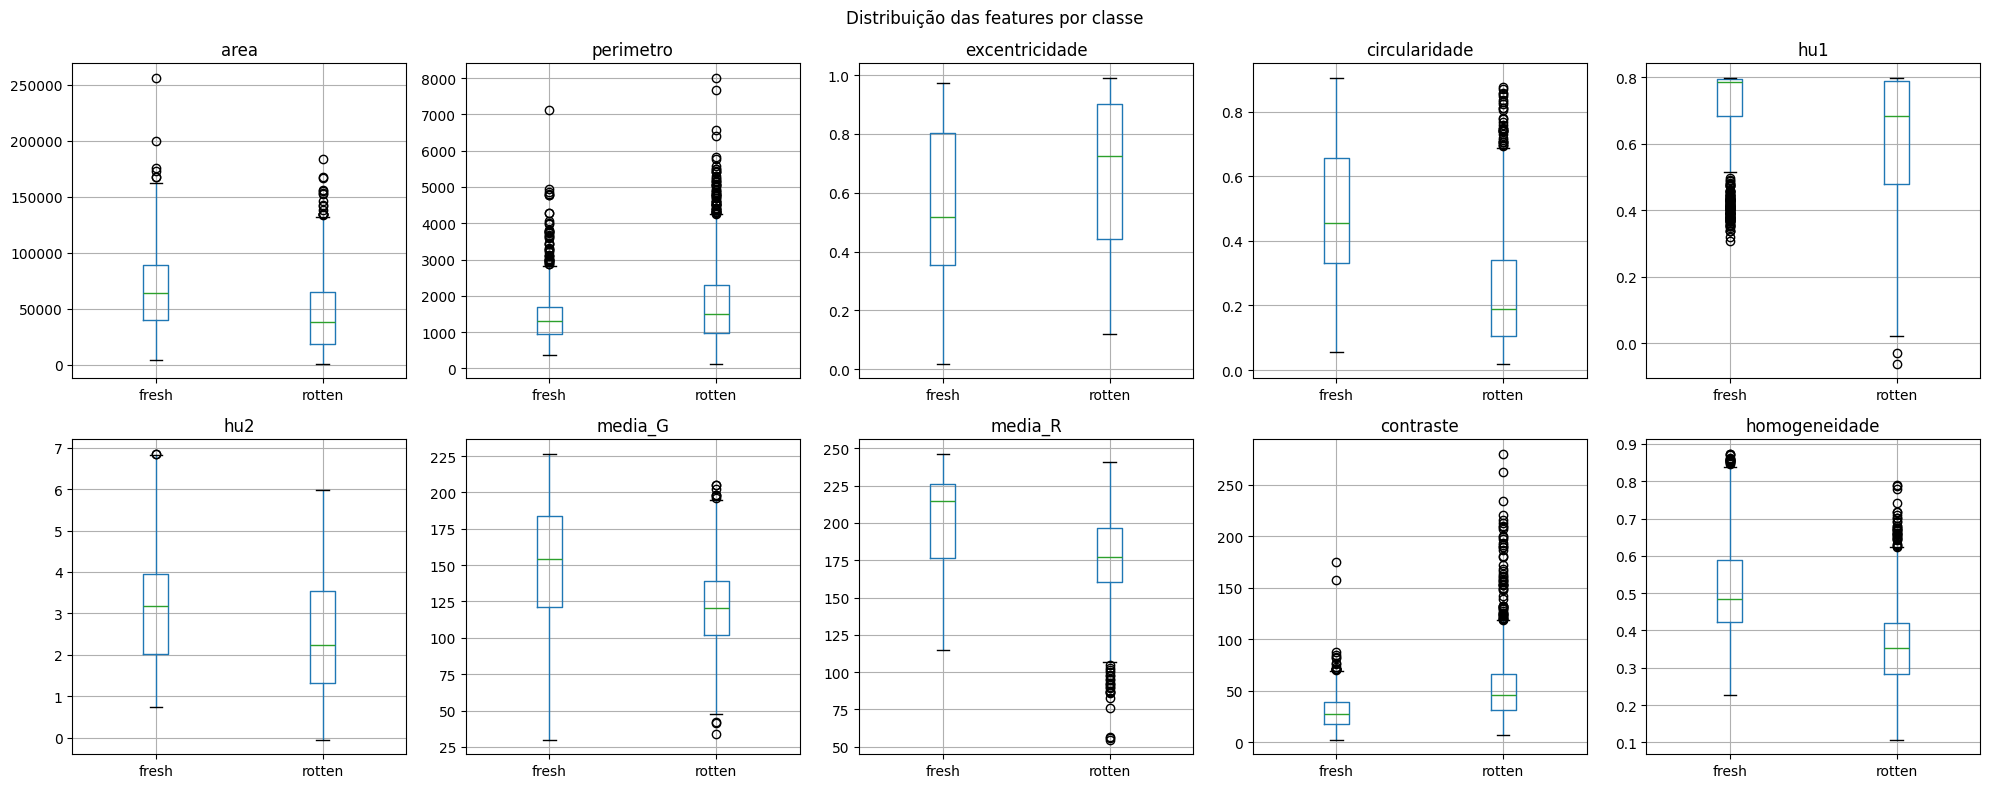

In [4]:
import matplotlib.pyplot as plt

df_plot = X.copy()
df_plot['classe'] = y

features_to_plot = ['area', 'perimetro', 'excentricidade', 'circularidade',
                    'hu1', 'hu2', 'media_G', 'media_R', 'contraste', 'homogeneidade']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, feat in enumerate(features_to_plot):
    df_plot.boxplot(column=feat, by='classe', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
plt.suptitle('Distribuição das features por classe')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'boxplot_features.png'), dpi=200)
plt.show()

In [17]:
medias = df_plot.groupby('classe').mean()
print("Médias das features por classe:")
display(medias)

diff = (medias.loc['fresh'] - medias.loc['rotten']).abs().sort_values(ascending=False)
print("\nFeatures diferença absoluta entre fresh e rotten:")
print(diff)

Médias das features por classe:


,area,perimetro,excentricidade,solidez,extensao,diam_eq,circularidade,hu1,hu2,hu3,...,media_B,std_B,media_G,std_G,media_R,std_R,contraste,homogeneidade,energia,correlacao
classe,,,,,,,,,,,,,,,,,,,,,
fresh,65977.807524,1407.124453,0.557438,0.878966,0.666727,278.522413,0.489214,0.715235,3.055103,3.835703,...,74.960525,27.620606,146.807931,31.375366,201.293469,27.433882,29.382939,0.516702,0.161140,0.994637
rotten,44612.266842,1780.960985,0.663006,0.759114,0.546392,221.277330,0.246851,0.619173,2.450432,3.401658,...,74.520991,28.828865,121.086633,36.716762,177.430238,36.086687,54.377791,0.362674,0.104193,0.991907



Features diferença absoluta entre fresh e rotten:
area              21365.540682
perimetro           373.836532
diam_eq              57.245083
media_G              25.721298
contraste            24.994852
media_R              23.863231
std_R                 8.652804
std_G                 5.341396
std_B                 1.208259
hu6                   1.113967
hu4                   0.927897
hu5                   0.798594
hu2                   0.604670
media_B               0.439534
hu3                   0.434046
circularidade         0.242362
homogeneidade         0.154028
extensao              0.120335
solidez               0.119851
excentricidade        0.105568
hu1                   0.096062
energia               0.056947
hu7                   0.030225
correlacao            0.002730
dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 1600 amostras
Teste:  686 amostras


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE)
}

## Métricas


Random Forest
Acurácia:  0.9519
Precisão:  0.9532
Recall:    0.9504
F1-score:  0.9518

Relatório completo:
              precision    recall  f1-score   support

       fresh       0.95      0.95      0.95       343
      rotten       0.95      0.95      0.95       343

    accuracy                           0.95       686
   macro avg       0.95      0.95      0.95       686
weighted avg       0.95      0.95      0.95       686



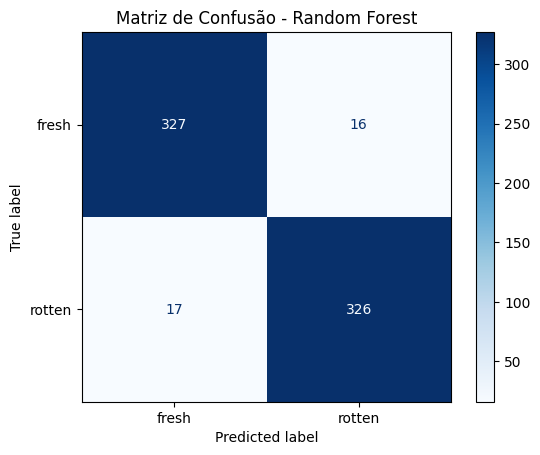


SVM (RBF)
Acurácia:  0.9344
Precisão:  0.9331
Recall:    0.9359
F1-score:  0.9345

Relatório completo:
              precision    recall  f1-score   support

       fresh       0.94      0.93      0.93       343
      rotten       0.93      0.94      0.93       343

    accuracy                           0.93       686
   macro avg       0.93      0.93      0.93       686
weighted avg       0.93      0.93      0.93       686



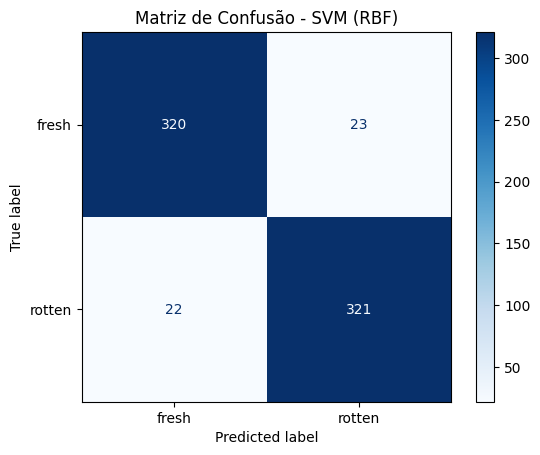

In [9]:
resultados = {}
for nome, modelo in modelos.items():
    print(f"\n{'='*40}\n{nome}\n{'='*40}")
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label='rotten')
    rec = recall_score(y_test, y_pred, average='binary', pos_label='rotten')
    f1 = f1_score(y_test, y_pred, average='binary', pos_label='rotten')
    
    print(f"Acurácia:  {acc:.4f}")
    print(f"Precisão:  {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nRelatório completo:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.show()
    
    resultados[nome] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'y_pred': y_pred
    }

In [10]:
tabela_metricas = pd.DataFrame(resultados).T
tabela_metricas = tabela_metricas[['Accuracy', 'Precision', 'Recall', 'F1-score']]
print("\nTABELA COMPARATIVA FINAL:")
display(tabela_metricas.round(4))

tabela_metricas.to_csv(os.path.join(output_dir, 'metricas_comparativas.csv'))


TABELA COMPARATIVA FINAL:


,Accuracy,Precision,Recall,F1-score
Random Forest,0.951895,0.953216,0.950437,0.951825
SVM (RBF),0.934402,0.93314,0.93586,0.934498


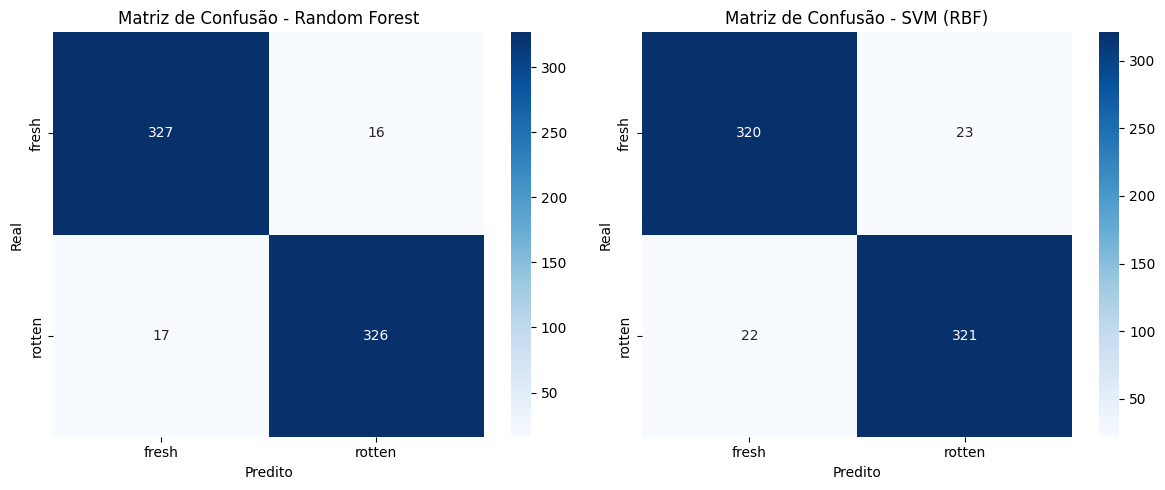

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nome, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=modelos[nome].classes_,
                yticklabels=modelos[nome].classes_)
    ax.set_title(f'Matriz de Confusão - {nome}')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'matrizes_comparativas.png'), dpi=200)
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

scorer_f1 = make_scorer(f1_score, pos_label='rotten')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring=scorer_f1)
    print(f"{nome} - F1 médio (CV): {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest - F1 médio (CV): 0.9362 ± 0.0063
SVM (RBF) - F1 médio (CV): 0.9239 ± 0.0088


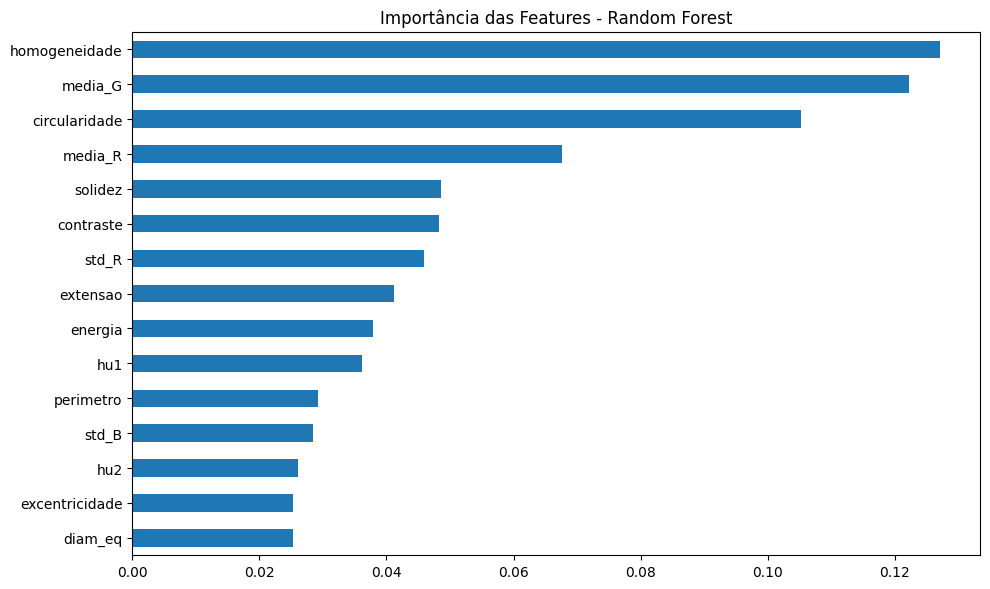

In [13]:
modelo_rf = modelos['Random Forest']
importances = modelo_rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.head(15).plot(kind='barh')
plt.title('Importância das Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'feature_importance.png'), dpi=200)
plt.show()

In [23]:
y_pred_rf = modelo_rf.predict(X_test_scaled)
y_pred_series = pd.Series(y_pred_rf, index=X_test.index)
erros_mask = y_test != y_pred_series
acertos_mask = ~erros_mask   # complemento: True onde acertou

indices_errados = y_test.index[erros_mask].tolist()

print(f"Total de erros: {len(indices_errados)}")
print("Índices de todos os erros:")
print(indices_errados)

print("\nAcertos por classe:")
print(y_test[acertos_mask].value_counts())
print("\nErros por classe:")
print(y_test[erros_mask].value_counts())

Total de erros: 33
Índices de todos os erros:
[1477, 406, 1061, 1217, 1379, 150, 1900, 1358, 642, 1244, 1135, 1113, 836, 1174, 563, 1921, 586, 480, 2151, 1584, 1269, 452, 1071, 123, 744, 1342, 1507, 1195, 1905, 826, 2194, 1229, 775]

Acertos por classe:
classe
fresh     327
rotten    326
Name: count, dtype: int64

Erros por classe:
classe
rotten    17
fresh     16
Name: count, dtype: int64


In [19]:
base_path = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\normal"
prep_base = r"E:\VISÃO COMPUTACIONAL\Projeto Final\DATASET\preprocessed\normal"
classes = ["fresh", "rotten"]

imagens_por_classe = {}
for classe in classes:
    pasta_classe = os.path.join(base_path, classe)
    imagens = []
    for raiz, subpastas, arquivos in os.walk(pasta_classe):
        for arquivo in arquivos:
            if arquivo.lower().endswith(('.png', '.jpg', '.jpeg')):
                imagens.append(os.path.join(raiz, arquivo))
    imagens.sort()
    imagens_por_classe[classe] = imagens

caminhos_completos = []
for classe in classes:
    for caminho_original in imagens_por_classe[classe]:
        rel_path = os.path.relpath(caminho_original, base_path)
        caminho_img = os.path.join(prep_base, rel_path)
        caminhos_completos.append(caminho_img)

print("Total de caminhos:", len(caminhos_completos))

Total de caminhos: 2286


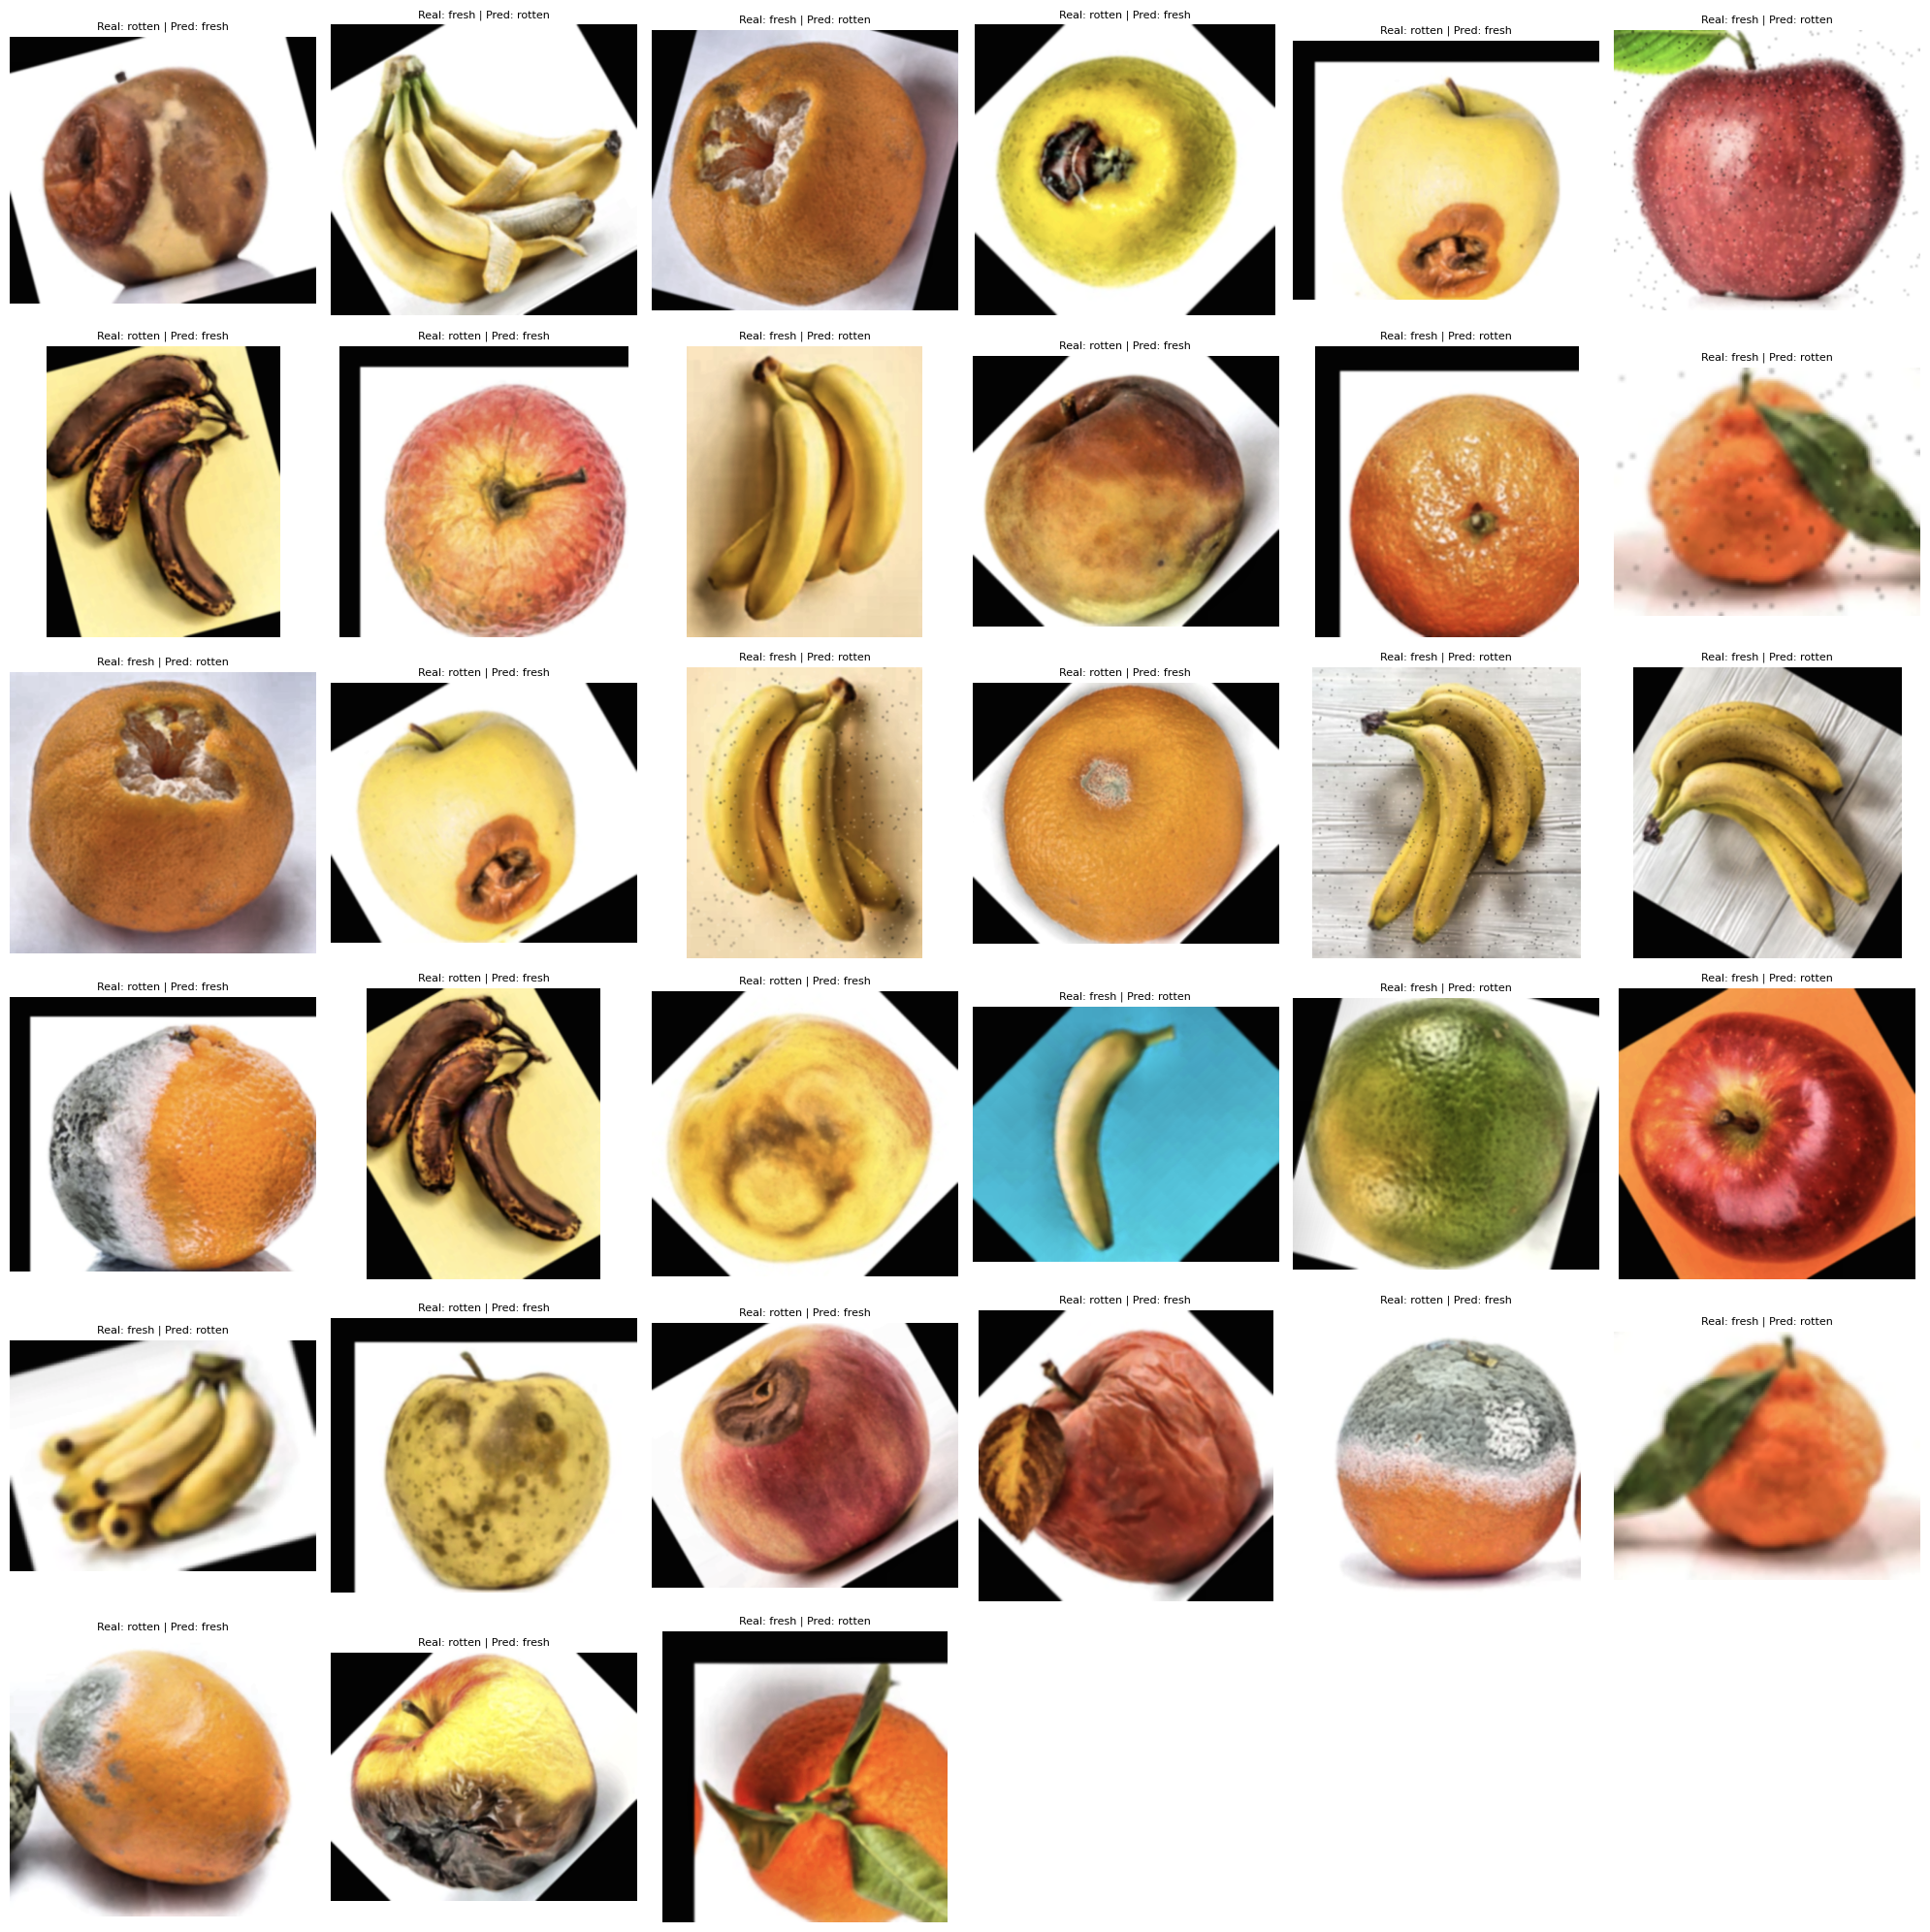

In [21]:
import math

num_erros = len(indices_errados)
cols = 6
rows = math.ceil(num_erros / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.ravel()

for i in range(rows * cols):
    ax = axes[i]
    if i < num_erros:
        idx = indices_errados[i]
        img_path = caminhos_completos[idx]
        img = cv2.imread(img_path)
        if img is None:
            img = carregar_imagem_bgr(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"Real: {y_test[idx]} | Pred: {y_pred_series[idx]}", fontsize=8)
    else:
        ax.axis('off')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'todos_erros.png'), dpi=150)
plt.show()